### 2025 T3 Lab 3 Specification
### Author: SongyuQi
### ZID: z5536858

In [3]:
import cv2
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import sys
import numpy as np 
import os 
from collections import Counter

In [4]:
#plt can show chinese
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [5]:
print("=== Loading Chinese MNIST ===")

csv_path = "Chinese_MINST_Dataset/chinese_mnist.csv"
df = pd.read_csv(csv_path)

print(f"Total records: {len(df)}")
print(f"CSV file columns: {list(df.columns)}")
print(df.head())


=== Loading Chinese MNIST ===
Total records: 15000
CSV file columns: ['suite_id', 'sample_id', 'code', 'value', 'character']
   suite_id  sample_id  code  value character
0         1          1    10      9         九
1         1         10    10      9         九
2         1          2    10      9         九
3         1          3    10      9         九
4         1          4    10      9         九


In [6]:
print("Character analysis:")
unique_characters = df['character'].unique()
unique_codes = df['code'].unique()
unique_values = df['value'].unique()

print(f"Unique characters: {len(unique_characters)}")
print(f"Unique codes: {len(unique_codes)}")
print(f"Unique values: {len(unique_values)}")
print(f"All characters: {sorted(unique_characters)}")

# statistics the number of samples for each character
class_counts = df['character'].value_counts().sort_index()
print(f"\neach character's samples:")
for char, count in class_counts.items():
    print(f"'{char}': {count} samples")


Character analysis:
Unique characters: 15
Unique codes: 15
Unique values: 15
All characters: ['一', '七', '万', '三', '九', '二', '五', '亿', '八', '六', '十', '千', '四', '百', '零']

each character's samples:
'一': 1000 samples
'七': 1000 samples
'万': 1000 samples
'三': 1000 samples
'九': 1000 samples
'二': 1000 samples
'五': 1000 samples
'亿': 1000 samples
'八': 1000 samples
'六': 1000 samples
'十': 1000 samples
'千': 1000 samples
'四': 1000 samples
'百': 1000 samples
'零': 1000 samples


In [7]:

print("Images anylasis:")
image_dir = "Chinese_MINST_Dataset/data/data"
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

print(f"Total images: {len(image_files)}")
print(f"Image file naming examples: {image_files[:5]}")

#analysis simple image
sample_image_path = os.path.join(image_dir, image_files[0])
sample_image = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
print(f"Image size: {sample_image.shape}")
print(f"Image data type: {sample_image.dtype}")
print(f"Pixel value range: {sample_image.min()} - {sample_image.max()}")


Images anylasis:
Total images: 15000
Image file naming examples: ['input_69_2_7.jpg', 'input_11_7_12.jpg', 'input_81_4_10.jpg', 'input_84_6_1.jpg', 'input_36_3_3.jpg']
Image size: (64, 64)
Image data type: uint8
Pixel value range: 0 - 140


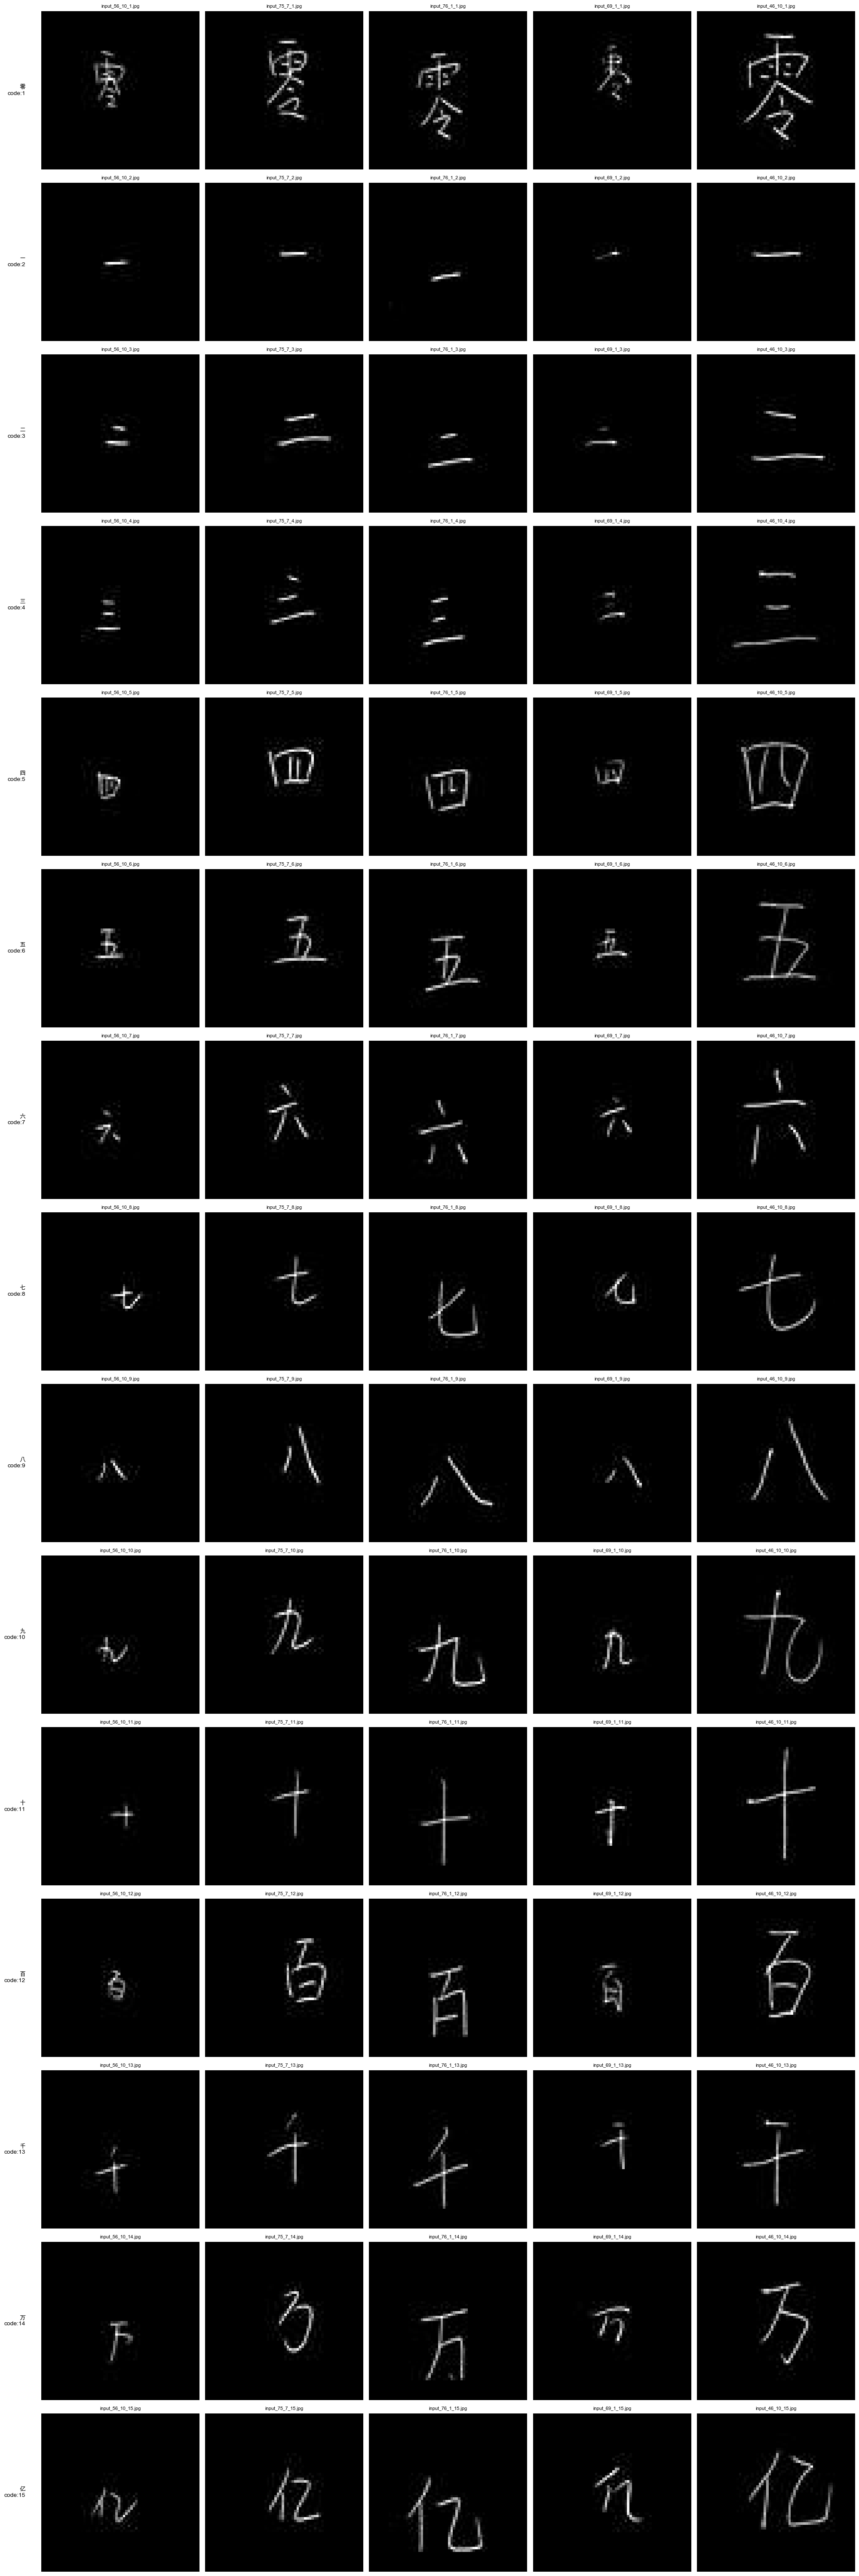

In [11]:
char_code_mapping = df[['character', 'code']].drop_duplicates().sort_values('code')
unique_characters_sorted = char_code_mapping['character'].tolist()

fig, axes = plt.subplots(15, 5, figsize=(20, 60))

for row, character in enumerate(unique_characters_sorted):
    char_samples = df[df['character'] == character]
    selected_samples = char_samples.sample(n=5, random_state=42)
    for col in range(5):
        ax = axes[row, col]
        
        if col < len(selected_samples):
            sample = selected_samples.iloc[col]
            suite_id = sample['suite_id']
            sample_id = sample['sample_id']
            code = sample['code']
            
            image_filename = f"input_{suite_id}_{sample_id}_{code}.jpg"
            image_path = os.path.join(image_dir, image_filename)
            
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"{image_filename}", fontsize=8)
            ax.axis('off')

    code_value = char_code_mapping[char_code_mapping['character'] == character]['code'].iloc[0]
    axes[row, 0].text(-0.1, 0.5, f"{character}\ncode:{code_value}", 
                     ha='right', va='center', transform=axes[row, 0].transAxes, 
                     fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [74]:
print("=== Step 3: Split dataset (fixed) ===")

from sklearn.model_selection import train_test_split

csv_path = "Chinese_MINST_Dataset/chinese_mnist.csv"
image_dir = "Chinese_MINST_Dataset/data/data"

df_paths = pd.read_csv(csv_path)
df_paths["filepath"] = df_paths.apply(
    lambda r: os.path.join(image_dir, f"input_{r['suite_id']}_{r['sample_id']}_{r['code']}.jpg"),
    axis=1
)

df_paths = df_paths[df_paths["filepath"].apply(os.path.exists)].reset_index(drop=True)

X = df_paths["filepath"].tolist()
y = df_paths["character"].tolist()


#first split
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y,
    test_size=1000,
    random_state=42,
    stratify=y
)

#second split
X_train, _, y_train, _ = train_test_split(
    X_tmp, y_tmp,
    train_size=5000,
    random_state=42,
    stratify=y_tmp
)

print(f"Train set: {len(X_train)}")
print(f"Test set: {len(X_test)}")

def show_distribution(name, labels):
    cnt = Counter(labels)
    print(f"{name} classes: {len(cnt)}")
    for k in sorted(cnt.keys()):
        print(f"  {k}: {cnt[k]}")

print("Distribution in TRAIN:")
show_distribution("TRAIN", y_train)

print("Distribution in TEST:")
show_distribution("TEST", y_test)

=== Step 3: Split dataset (fixed) ===
Train set: 5000
Test set: 1000
Distribution in TRAIN:
TRAIN classes: 15
  一: 334
  七: 333
  万: 333
  三: 333
  九: 333
  二: 334
  五: 333
  亿: 333
  八: 333
  六: 334
  十: 333
  千: 334
  四: 333
  百: 334
  零: 333
Distribution in TEST:
TEST classes: 15
  一: 66
  七: 67
  万: 67
  三: 67
  九: 67
  二: 66
  五: 67
  亿: 67
  八: 67
  六: 66
  十: 67
  千: 66
  四: 67
  百: 66
  零: 67


In [75]:
print("=== Step 4: Reshaping")

def load_and_reshape_images(image_paths):
    """
    this function takes a list of image paths,
    then loads each image in grayscale mode,
    flattens it to a 1D vector,
    and stacks all vectors into a NumPy array.
    """
    processed_images = []
    for path in image_paths:
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        
        if image is not None:
            flat_vector = image.flatten() #flattens the image to a 1D vector
            
            processed_images.append(flat_vector)
    return np.array(processed_images)

X_train_reshaped = load_and_reshape_images(X_train)
X_test_reshaped = load_and_reshape_images(X_test)

print( "X_train_reshaped.shape:",X_train_reshaped.shape)
print( "X_test_reshaped.shape:",X_test_reshaped.shape)

=== Step 4: Reshaping
X_train_reshaped.shape: (5000, 4096)
X_test_reshaped.shape: (1000, 4096)


In [76]:
print("=== Step 5: Initialise classifiers ===")
from sklearn.neighbors import KNeighborsClassifier
#initialise KNN classifier, set k=3
knn_classifier = KNeighborsClassifier(n_neighbors=3)
print(knn_classifier)


=== Step 5: Initialise classifiers ===
KNeighborsClassifier(n_neighbors=3)


In [77]:
from sklearn.tree import DecisionTreeClassifier

# Initialise Decision Tree classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
print(dt_classifier)

DecisionTreeClassifier(random_state=42)


In [78]:
from sklearn.linear_model import SGDClassifier

# initialise SGD
sgd_classifier = SGDClassifier(max_iter=250, random_state=42)
print(sgd_classifier)

SGDClassifier(max_iter=250, random_state=42)


In [79]:
print("=== Step 6: Fit the classifier ===")
#KNN
print(X_train_reshaped.shape==(5000, 4096))
knn_classifier.fit(X_train_reshaped, y_train)


=== Step 6: Fit the classifier ===
True


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [80]:
#DT
dt_classifier.fit(X_train_reshaped, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [81]:
#SGD
sgd_classifier.fit(X_train_reshaped, y_train)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,250
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [82]:
print("=== Step 7: Evaluate the prediction from train to test ===")
#KNN
y_pred_knn = knn_classifier.predict(X_test_reshaped)


=== Step 7: Evaluate the prediction from train to test ===


In [83]:
#DT
y_pred_dt = dt_classifier.predict(X_test_reshaped)

In [84]:
#SGD
y_pred_sgd = sgd_classifier.predict(X_test_reshaped)

In [85]:
print("Step 8: Performance Evaluation")
# KNN
from sklearn.metrics import classification_report, confusion_matrix

print("KNN performance report (k=3):")
print(classification_report(y_test, y_pred_knn))

print("KNN confuse matrix:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

Step 8: Performance Evaluation
KNN performance report (k=3):
              precision    recall  f1-score   support

           一       0.15      0.95      0.26        66
           七       0.38      0.30      0.33        67
           万       0.22      0.27      0.24        67
           三       0.30      0.37      0.33        67
           九       0.48      0.21      0.29        67
           二       0.35      0.38      0.36        66
           五       0.71      0.15      0.25        67
           亿       0.92      0.18      0.30        67
           八       0.91      0.87      0.89        67
           六       0.42      0.24      0.31        66
           十       0.49      0.52      0.50        67
           千       0.59      0.20      0.30        66
           四       0.86      0.18      0.30        67
           百       1.00      0.11      0.19        66
           零       0.92      0.33      0.48        67

    accuracy                           0.35      1000
   macro avg       

In [86]:

print("DT performance report:")
print(classification_report(y_test, y_pred_dt))

print("DT confuse matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

DT performance report:
              precision    recall  f1-score   support

           一       0.58      0.64      0.61        66
           七       0.14      0.16      0.15        67
           万       0.09      0.10      0.10        67
           三       0.18      0.18      0.18        67
           九       0.14      0.15      0.15        67
           二       0.26      0.24      0.25        66
           五       0.24      0.22      0.23        67
           亿       0.28      0.28      0.28        67
           八       0.33      0.36      0.35        67
           六       0.14      0.18      0.16        66
           十       0.36      0.33      0.34        67
           千       0.21      0.20      0.20        66
           四       0.27      0.21      0.24        67
           百       0.16      0.17      0.16        66
           零       0.41      0.27      0.32        67

    accuracy                           0.25      1000
   macro avg       0.25      0.25      0.25      1000
wei

In [87]:
print("SGD performance report:")
print(classification_report(y_test, y_pred_sgd))

print("SGD confuse matrix:")
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
print(cm_sgd)

SGD performance report:
              precision    recall  f1-score   support

           一       0.43      0.41      0.42        66
           七       0.30      0.27      0.28        67
           万       0.26      0.22      0.24        67
           三       0.42      0.33      0.37        67
           九       0.20      0.36      0.26        67
           二       0.29      0.33      0.31        66
           五       0.33      0.30      0.31        67
           亿       0.31      0.28      0.30        67
           八       0.52      0.43      0.47        67
           六       0.23      0.12      0.16        66
           十       0.38      0.48      0.42        67
           千       0.32      0.26      0.29        66
           四       0.26      0.39      0.31        67
           百       0.18      0.17      0.17        66
           零       0.43      0.40      0.42        67

    accuracy                           0.32      1000
   macro avg       0.32      0.32      0.32      1000
we

In [88]:
#Model accuracy summary
print("Model accuracy summary:")
print("KNN accuracy:", knn_classifier.score(X_test_reshaped, y_test))
print("DT accuracy:", dt_classifier.score(X_test_reshaped, y_test))
print("SGD accuracy:", sgd_classifier.score(X_test_reshaped, y_test))

Model accuracy summary:
KNN accuracy: 0.35
DT accuracy: 0.246
SGD accuracy: 0.317


In [89]:
#repeat train from training images 5000 to 10000
print("=== Double training images ===")
#initial X and y
X = df_paths["filepath"].tolist()
y = df_paths["character"].tolist()

#first split
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y,
    test_size=1000,
    random_state=42,
    stratify=y
)

#second split
X_train, _, y_train, _ = train_test_split(
    X_tmp, y_tmp,
    train_size=10000,
    random_state=42,
    stratify=y_tmp
)

print(f"Train set: {len(X_train)}")
print(f"Test set: {len(X_test)}")

print("Distribution in TRAIN:")
show_distribution("TRAIN", y_train)

print("Distribution in TEST:")
show_distribution("TEST", y_test)


=== Double training images ===
Train set: 10000
Test set: 1000
Distribution in TRAIN:
TRAIN classes: 15
  一: 667
  七: 667
  万: 667
  三: 666
  九: 666
  二: 667
  五: 666
  亿: 667
  八: 666
  六: 667
  十: 667
  千: 667
  四: 667
  百: 667
  零: 666
Distribution in TEST:
TEST classes: 15
  一: 66
  七: 67
  万: 67
  三: 67
  九: 67
  二: 66
  五: 67
  亿: 67
  八: 67
  六: 66
  十: 67
  千: 66
  四: 67
  百: 66
  零: 67


In [90]:
#reshaping
X_train_reshaped = load_and_reshape_images(X_train)
X_test_reshaped = load_and_reshape_images(X_test)

print( "X_train_reshaped.shape:",X_train_reshaped.shape)
print( "X_test_reshaped.shape:",X_test_reshaped.shape)

X_train_reshaped.shape: (10000, 4096)
X_test_reshaped.shape: (1000, 4096)


In [91]:
print("=== KNN ===")
knn_classifier.fit(X_train_reshaped, y_train)
y_pred_knn = knn_classifier.predict(X_test_reshaped)
print("Double images KNN performance report (k=3):")
print(classification_report(y_test, y_pred_knn))

print("Double images KNN confuse matrix:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

=== KNN ===
Double images KNN performance report (k=3):
              precision    recall  f1-score   support

           一       0.18      0.97      0.31        66
           七       0.47      0.39      0.43        67
           万       0.31      0.39      0.34        67
           三       0.41      0.43      0.42        67
           九       0.68      0.25      0.37        67
           二       0.39      0.45      0.42        66
           五       0.74      0.21      0.33        67
           亿       1.00      0.27      0.42        67
           八       0.90      0.96      0.93        67
           六       0.53      0.32      0.40        66
           十       0.49      0.61      0.54        67
           千       0.68      0.35      0.46        66
           四       1.00      0.24      0.39        67
           百       0.87      0.30      0.45        66
           零       1.00      0.49      0.66        67

    accuracy                           0.44      1000
   macro avg       0.64 

In [92]:
print("=== DT ===")
dt_classifier.fit(X_train_reshaped, y_train)
y_pred_dt = dt_classifier.predict(X_test_reshaped)
print("Double images DT performance report:")
print(classification_report(y_test, y_pred_dt))

print("Double images DT confuse matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

=== DT ===
Double images DT performance report:
              precision    recall  f1-score   support

           一       0.68      0.65      0.67        66
           七       0.23      0.21      0.22        67
           万       0.10      0.09      0.09        67
           三       0.21      0.22      0.22        67
           九       0.24      0.22      0.23        67
           二       0.31      0.35      0.33        66
           五       0.25      0.27      0.26        67
           亿       0.25      0.25      0.25        67
           八       0.37      0.48      0.42        67
           六       0.21      0.21      0.21        66
           十       0.49      0.49      0.49        67
           千       0.36      0.41      0.38        66
           四       0.25      0.21      0.23        67
           百       0.17      0.18      0.18        66
           零       0.57      0.34      0.43        67

    accuracy                           0.31      1000
   macro avg       0.31      0.3

In [93]:
print("=== SGD ===")
sgd_classifier.fit(X_train_reshaped, y_train)
y_pred_sgd = sgd_classifier.predict(X_test_reshaped)
print("Double images SGD performance report:")
print(classification_report(y_test, y_pred_sgd))
print("Double images SGD confuse matrix:")
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
print(cm_sgd)


=== SGD ===
Double images SGD performance report:
              precision    recall  f1-score   support

           一       0.57      0.36      0.44        66
           七       0.23      0.31      0.26        67
           万       0.20      0.25      0.22        67
           三       0.35      0.28      0.31        67
           九       0.29      0.24      0.26        67
           二       0.33      0.32      0.33        66
           五       0.26      0.46      0.33        67
           亿       0.20      0.37      0.26        67
           八       0.56      0.43      0.49        67
           六       0.19      0.08      0.11        66
           十       0.42      0.40      0.41        67
           千       0.39      0.33      0.36        66
           四       0.29      0.15      0.20        67
           百       0.24      0.24      0.24        66
           零       0.46      0.43      0.45        67

    accuracy                           0.31      1000
   macro avg       0.33      0

In [94]:
#Model accuracy summary
print("Model accuracy summary:")
print("KNN accuracy:", knn_classifier.score(X_test_reshaped, y_test))
print("DT accuracy:", dt_classifier.score(X_test_reshaped, y_test))
print("SGD accuracy:", sgd_classifier.score(X_test_reshaped, y_test))

Model accuracy summary:
KNN accuracy: 0.442
DT accuracy: 0.306
SGD accuracy: 0.312
